<a href="https://colab.research.google.com/github/NikhilGeorge01/ML-Prac/blob/main/GradientDescent_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATA CLEANBING AND PREPROCESSING


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [42]:
URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.csv"
df = pd.read_csv(URL, header=None)

In [43]:
X = df.loc[:, 0:12]
y = df.loc[:, 13]

# GRADIENT DESCENT

FEATURE SCALING

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

GRADIENT DESCENT


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

In [48]:
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42)
learning_rates = ['constant', 'optimal', 'invscaling', 'adaptive']
max_iters = [0.001, 0.01, 0.1]

for lr in learning_rates:
    for mi in max_iters:
        print(f"Training with learning_rate={lr} and max_iter={mi}")
        model = SGDRegressor(max_iter=200, learning_rate=lr, eta0=mi, random_state=42)
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        mse = mean_squared_error(y_test, y_pred)
        print(f"Mean Squared Error: {mse}")
        print("-" * 30)

Training with learning_rate=constant and max_iter=0.001
Mean Squared Error: 25.113133863455243
------------------------------
Training with learning_rate=constant and max_iter=0.01
Mean Squared Error: 30.639928066955825
------------------------------
Training with learning_rate=constant and max_iter=0.1
Mean Squared Error: 132914725007134.61
------------------------------
Training with learning_rate=optimal and max_iter=0.001
Mean Squared Error: 6.3506005736446e+24
------------------------------
Training with learning_rate=optimal and max_iter=0.01
Mean Squared Error: 6.3506005736446e+24
------------------------------
Training with learning_rate=optimal and max_iter=0.1
Mean Squared Error: 6.3506005736446e+24
------------------------------
Training with learning_rate=invscaling and max_iter=0.001
Mean Squared Error: 26.050019766745223
------------------------------
Training with learning_rate=invscaling and max_iter=0.01
Mean Squared Error: 25.1124755075724
----------------------------

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


# REGULARIZATION

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error

In [28]:
URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.csv"
df = pd.read_csv(URL, header=None)

In [30]:
X = df.loc[:100, 5].values
y = df.loc[:100, 13].values

LASSO REGULARIZATION

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       506 non-null    float64
 1   1       506 non-null    float64
 2   2       506 non-null    float64
 3   3       506 non-null    int64  
 4   4       506 non-null    float64
 5   5       506 non-null    float64
 6   6       506 non-null    float64
 7   7       506 non-null    float64
 8   8       506 non-null    int64  
 9   9       506 non-null    float64
 10  10      506 non-null    float64
 11  11      506 non-null    float64
 12  12      506 non-null    float64
 13  13      506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [32]:
X_reshaped = X.reshape(-1, 1)
y_reshaped = y.reshape(-1, 1)


In [33]:
lasso = Lasso(alpha=10)

In [34]:
lasso.fit(X_reshaped, y_reshaped)

Lasso(alpha=10)

In [35]:
y_pred = lasso.predict(X_reshaped)

In [36]:
mse = mean_squared_error(y_reshaped, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Model Coefficients: {lasso.coef_}n")

Mean Squared Error: 34.709124595627884
Model Coefficients: [0.]n


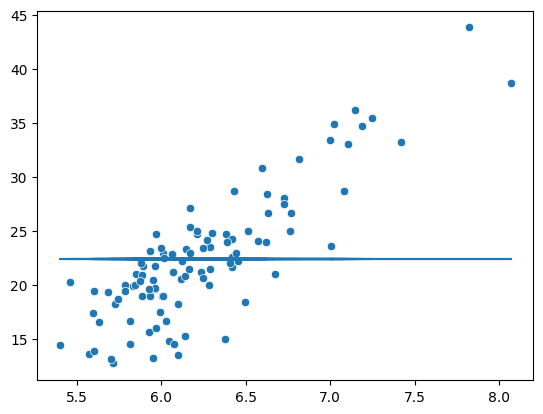

In [39]:
sns.scatterplot(x=X, y=y)
plt.plot(X_reshaped, y_pred)
plt.show()


RIDGE REGULARIZATION

Mean Squared Error: 25.96309109305436
Model Coefficients: [1.98542524]n


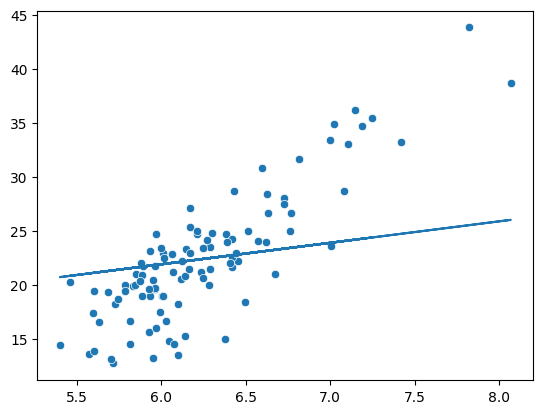

In [41]:
ridge = Ridge(alpha=100)
ridge.fit(X_reshaped, y_reshaped)
y_pred = ridge.predict(X_reshaped)

mse = mean_squared_error(y_reshaped, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Model Coefficients: {ridge.coef_}n")

sns.scatterplot(x=X, y=y)
plt.plot(X_reshaped, y_pred)
plt.show()
